# Frequency domain examples

Example code which computes eigenvalues and eigenvectors of linearized radial perturbations of perfect and Eckart fluid stars. See the notebook in the "Long" directory for the full range of functions offered.

In [ ]:
include("params.jl");

Star(5.5e15, 0.004084389065951561, 0.0016682234042064664, 100.0, 1.0, NeutronStarOscillations.var"#EOS_ε#2"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#EOS_p#3"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#dp_dε#4"{Float64, Float64}(100.0, 2.0), NeutronStarOscillations.var"#d2p_dε2#5"{Float64, Float64}(100.0, 2.0), 0.01, 0.01, 15.0, 1.5, 20.0, 1.0, 1.6682234042064662e-9, 1.6682234042064664e-6, "./Results/Data/", "./Results/Figures/", 1.0e-15, 10, 100000000000, 1.0e-15, 1.0e-12, 1.0e-12, 200, 5, Main.xi_ID, Main.xi_dt_ID, Main.du_ID, Main.du_dr_ID, Main.du_dt_ID, Main.de_ID, Main.de_dr_ID, Main.de_dt_ID, 0.2, 0.1, 0.0005, 0.04, 50, 0.05, -1)

In [2]:
nPointsMatrix = 500;
h1_shoot = 4e-2;
h_TOV = 1e-5;

## Perfect fluid star

In [3]:
cowling = false;

In [4]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 15.342065 seconds (94.71 M allocations: 3.391 GiB, 13.77% gc time, 113.28% compilation time: 5% of which was recompilation)


In [5]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);

In [6]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);

In [7]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [0.5728046179879316, 7.576141587536057, 11.599944442218144, 15.406455563938433, 19.15052922714718]


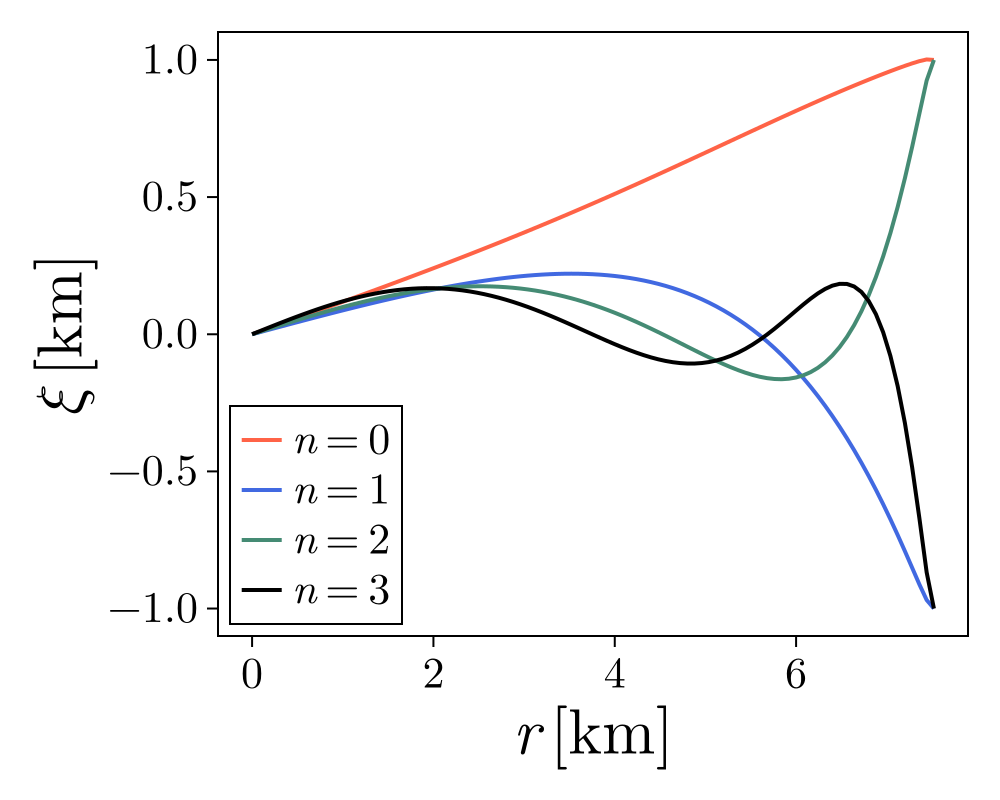

In [8]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h1_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Eckart star

In [9]:
cowling = false;

In [10]:
@time compute_eigensystem(Eckart_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  9.925534 seconds (81.07 M allocations: 3.149 GiB, 14.38% gc time, 96.54% compilation time)


In [11]:
# load eigensystems. Eigenvalues are (complex-valued) linear frequencies, i.e., ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(Eckart_star, h1_shoot, cowling);

In [12]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) Eckart shooting method return codes: ", ret_1)
# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) Eckart fluid frequencies (kHz): ", shooting_freqs_1)

*** NonlinearSolve return codes for shooting method ***
(Low res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) Eckart fluid frequencies (kHz): ComplexF64[0.572763848351077 - 0.0076473797818237465im, 7.576082313796083 - 0.033117011006929944im, 11.599770575787296 - 0.07024803991401851im, 15.406073161113788 - 0.12013584141414574im, 19.1498096973678 - 0.18320724476282568im]


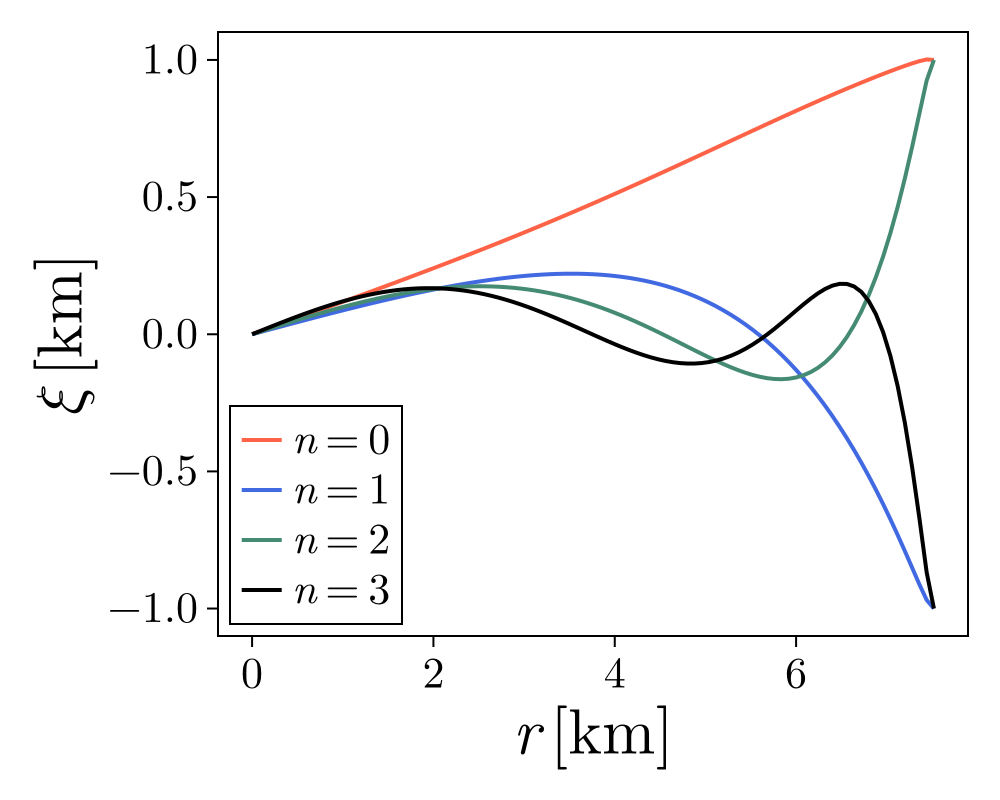

In [13]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, Eckart_star, method; h=h1_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);